# Istanbul Airbnb Market Analysis (2026)

This project analyzes Istanbul Airbnb listings to identify what drives listing success using real market data from Inside Airbnb.

The core business question is:
**Why are many listings inactive, and which factors are associated with higher occupancy and revenue?**

## Introduction

Istanbul has thousands of Airbnb listings, but listing availability does not guarantee market performance. This project builds a data-driven market review to understand which listings are active, which are inactive, and what characteristics separate both groups.

## Problem Statement

During early exploration, a large share of listings showed zero estimated occupancy over the previous 365 days. This indicates a performance gap in the market and raises a core business question:
- Why do some listings attract bookings while many others remain inactive?

## Goal

Build an analytical framework that identifies success signals in Istanbul Airbnb listings by measuring:
1. Occupancy activity
2. Revenue potential
3. Price positioning by neighborhood and listing profile

## Factors Used

The analysis focuses on factors with direct business relevance:
- **Location:** `neighbourhood_cleansed`
- **Listing format:** `room_type`, `property_type`
- **Capacity/features:** `accommodates`, `bedrooms`, `beds`, `bathrooms`
- **Host quality:** `host_is_superhost`
- **Demand/engagement:** `number_of_reviews`, `review_scores_rating`
- **Performance targets:** `estimated_occupancy_l365d`, `estimated_revenue_l365d`, `price`

## How the Goal Was Detected from Data

The goal was not assumed before analysis. It was discovered through structured data review:
1. Audit of missing values and dtypes
2. Price outlier detection and correction
3. Distribution checks for occupancy and revenue
4. Active vs inactive segmentation using `estimated_occupancy_l365d`

This process revealed that inactive listings form a major market share, so the project was framed around explaining that gap.

## Data Source

- **Source:** Inside Airbnb (Istanbul, Marmara, Turkey)
- **Snapshot:** 30 June 2026
- **Main file used for analysis:** `listings.csv.gz`
- **Supporting files:** `calendar.csv.gz`, `reviews.csv.gz`, `neighbourhoods.csv`, `neighbourhoods.geojson`

## Data Summary

- Initial listings: **26,631**
- Cleaned analytical sample: **23,467**
- Key quality issues found:
  - Missing values in `beds`, `bathrooms`, `review_scores_rating`
  - Extreme price outliers that distort averages
- Key segmentation:
  - **Active listings:** occupancy > 0
  - **Inactive listings:** occupancy = 0

## Data Structure

The analysis is organized around the listing-level grain in listings.csv.gz. Calendar and reviews files are supporting datasets and should be aggregated before joining to listings.

## Data Review

Missing values were found in beds, bathrooms, and review_scores_rating. Extreme price outliers were also detected and removed to keep averages meaningful.


In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
listings = pd.read_csv(r'C:\Users\a\Istanbul-Airbnb-Analysis\data\raw\listings.csv.gz')

In [187]:
listings.shape

(26631, 90)

In [188]:
listings.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,25436,https://www.airbnb.com/rooms/25436,20260630053558,2026-07-03,previous scrape,In the forest Sea view Two minutes to the city.,Our house is in Bebek Koru. If you want villag...,NaN,https://a0.muscache.com/pictures/b64c3ef0-2256...,105823,...,NaN,NaN,NaN,NaN,NaN,1,1,0,0,NaN
1,34177,https://www.airbnb.com/rooms/34177,20260630053558,2026-07-03,previous scrape,PETIT HOUSE,My petit house is located in the bosphorous an...,NaN,https://a0.muscache.com/pictures/47356451/c288...,147330,...,4.81,4.69,4.81,NaN,NaN,2,2,0,0,0.13
2,42835,https://www.airbnb.com/rooms/42835,20260630053558,2026-07-03,previous scrape,Cozy apartment in the heart of Istanbul,Welcome to our cozy 2-bedroom apartment locate...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,187026,...,NaN,NaN,NaN,NaN,NaN,3,1,2,0,NaN
3,44421,https://www.airbnb.com/rooms/44421,20260630053558,2026-06-30,city scrape,Beautiful Studio With A View,My studio is a pleasing two side oriented open...,NaN,https://a0.muscache.com/pictures/4625647/6d460...,194194,...,4.68,4.86,4.72,34-421,NaN,1,1,0,0,0.47
4,73477,https://www.airbnb.com/rooms/73477,20260630053558,2026-07-03,previous scrape,Sea View Apartment in Taksim/ Center of Istanbul,Sea View Apartment in Taksim/ Center of Istanbul,NaN,https://a0.muscache.com/pictures/409813ff-21c0...,383789,...,5.00,5.00,4.91,NaN,NaN,1,1,0,0,0.21


In [189]:
listings.columns.to_list()

['id',
 'listing_url',
 'scrape_id',
 'last_scraped',
 'source',
 'name',
 'description',
 'neighborhood_overview',
 'picture_url',
 'host_id',
 'host_url',
 'host_profile_id',
 'host_profile_url',
 'host_name',
 'host_since',
 'hosts_time_as_user_years',
 'hosts_time_as_user_months',
 'hosts_time_as_host_years',
 'hosts_time_as_host_months',
 'host_location',
 'host_about',
 'host_response_time',
 'host_response_rate',
 'host_acceptance_rate',
 'host_is_superhost',
 'host_thumbnail_url',
 'host_picture_url',
 'host_neighbourhood',
 'host_listings_count',
 'host_total_listings_count',
 'host_verifications',
 'host_has_profile_pic',
 'host_identity_verified',
 'neighbourhood',
 'neighbourhood_cleansed',
 'neighbourhood_group_cleansed',
 'latitude',
 'longitude',
 'property_type',
 'room_type',
 'accommodates',
 'bathrooms',
 'bathrooms_text',
 'bedrooms',
 'beds',
 'amenities',
 'price',
 'price_quote_checkin_date',
 'price_quote_checkout_date',
 'price_quote_total_price',
 'price_quote

In [190]:
cols = [
    'id',
    'neighbourhood_cleansed',
    'room_type',
    'property_type',
    'price',
    'accommodates',
    'bedrooms',
    'beds',
    'bathrooms',
    'host_is_superhost',
    'instant_bookable',
    'number_of_reviews',
    'review_scores_rating',
    'estimated_occupancy_l365d',
    'estimated_revenue_l365d'
]

df = listings[cols].copy()
df.head()

,id,neighbourhood_cleansed,room_type,property_type,price,accommodates,bedrooms,beds,bathrooms,host_is_superhost,instant_bookable,number_of_reviews,review_scores_rating,estimated_occupancy_l365d,estimated_revenue_l365d
0,25436,Besiktas,Entire home/apt,Entire rental unit,NaN,3,2.0,NaN,NaN,f,NaN,0,NaN,0,NaN
1,34177,Besiktas,Entire home/apt,Entire home,"$1,356.82",3,1.0,NaN,NaN,f,NaN,16,4.69,0,0.0
2,42835,Sisli,Entire home/apt,Entire rental unit,NaN,4,1.0,NaN,NaN,f,NaN,0,NaN,0,NaN
3,44421,Beyoglu,Entire home/apt,Entire loft,"$2,583.67",2,1.0,1.0,1.0,f,NaN,91,4.66,24,62008.0
4,73477,Beyoglu,Entire home/apt,Entire rental unit,NaN,2,1.0,NaN,NaN,f,NaN,11,5.00,0,NaN


In [191]:
df.isna().sum().sort_values(ascending=False)

instant_bookable             26631
bathrooms                    12190
beds                         11449
review_scores_rating          9757
bedrooms                      3705
price                         2688
estimated_revenue_l365d       2688
accommodates                     0
property_type                    0
neighbourhood_cleansed           0
room_type                        0
id                               0
host_is_superhost                0
number_of_reviews                0
estimated_occupancy_l365d        0
dtype: int64

In [192]:
df = df.drop(columns=['instant_bookable'])
df.head()

,id,neighbourhood_cleansed,room_type,property_type,price,accommodates,bedrooms,beds,bathrooms,host_is_superhost,number_of_reviews,review_scores_rating,estimated_occupancy_l365d,estimated_revenue_l365d
0,25436,Besiktas,Entire home/apt,Entire rental unit,NaN,3,2.0,NaN,NaN,f,0,NaN,0,NaN
1,34177,Besiktas,Entire home/apt,Entire home,"$1,356.82",3,1.0,NaN,NaN,f,16,4.69,0,0.0
2,42835,Sisli,Entire home/apt,Entire rental unit,NaN,4,1.0,NaN,NaN,f,0,NaN,0,NaN
3,44421,Beyoglu,Entire home/apt,Entire loft,"$2,583.67",2,1.0,1.0,1.0,f,91,4.66,24,62008.0
4,73477,Beyoglu,Entire home/apt,Entire rental unit,NaN,2,1.0,NaN,NaN,f,11,5.00,0,NaN


In [193]:
# Clean price
df['price_num'] = (
    df['price']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
)
df['price_num'] = pd.to_numeric(df['price_num'], errors='coerce')

In [194]:
df['price_num'].describe()

count    2.394300e+04
mean     4.347112e+03
std      1.481762e+04
min      1.240000e+01
25%      1.008825e+03
50%      2.853000e+03
75%      5.190035e+03
max      1.706000e+06
Name: price_num, dtype: float64

In [195]:
df['price_num'].sort_values(ascending=False).head(10)

574      1706000.45
11252     688831.11
17638     631244.50
7060      601146.35
4719      532491.00
7183      203112.89
22881     148987.00
13335     143871.63
21096     141610.00
21090     127012.00
Name: price_num, dtype: float64

In [196]:
df.head()

,id,neighbourhood_cleansed,room_type,property_type,price,accommodates,bedrooms,beds,bathrooms,host_is_superhost,number_of_reviews,review_scores_rating,estimated_occupancy_l365d,estimated_revenue_l365d,price_num
0,25436,Besiktas,Entire home/apt,Entire rental unit,NaN,3,2.0,NaN,NaN,f,0,NaN,0,NaN,NaN
1,34177,Besiktas,Entire home/apt,Entire home,"$1,356.82",3,1.0,NaN,NaN,f,16,4.69,0,0.0,1356.82
2,42835,Sisli,Entire home/apt,Entire rental unit,NaN,4,1.0,NaN,NaN,f,0,NaN,0,NaN,NaN
3,44421,Beyoglu,Entire home/apt,Entire loft,"$2,583.67",2,1.0,1.0,1.0,f,91,4.66,24,62008.0,2583.67
4,73477,Beyoglu,Entire home/apt,Entire rental unit,NaN,2,1.0,NaN,NaN,f,11,5.00,0,NaN,NaN


In [197]:
# Clean other numeric columns
df['bedrooms'] = pd.to_numeric(df['bedrooms'], errors='coerce')
df['beds'] = pd.to_numeric(df['beds'], errors='coerce')
df['bathrooms'] = pd.to_numeric(df['bathrooms'], errors='coerce')
df['review_scores_rating'] = pd.to_numeric(df['review_scores_rating'], errors='coerce')
df['review_scores_rating'] = pd.to_numeric(df['review_scores_rating'], errors='coerce')

In [198]:
df['host_is_superhost'] = df['host_is_superhost'].astype(str).str.lower().eq('t')

In [199]:
# Drop missing price rows
df = df.dropna(subset=['price_num']).copy()

In [200]:
# Remove extreme luxury outliers
q99 = df['price_num'].quantile(0.99)
df = df[df['price_num'] <= q99].copy()

In [201]:
# keep a clean final price column
df['price'] = df['price_num']

In [202]:
df = df[
    [
        'id',
        'neighbourhood_cleansed',
        'room_type',
        'property_type',
        'price',
        'accommodates',
        'bedrooms',
        'beds',
        'bathrooms',
        'host_is_superhost',
        'number_of_reviews',
        'review_scores_rating',
        'estimated_occupancy_l365d',
        'estimated_revenue_l365d'
    ]
].copy()

In [203]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23705 entries, 1 to 26630
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         23705 non-null  int64  
 1   neighbourhood_cleansed     23705 non-null  object 
 2   room_type                  23705 non-null  object 
 3   property_type              23705 non-null  object 
 4   price                      23705 non-null  float64
 5   accommodates               23705 non-null  int64  
 6   bedrooms                   20563 non-null  float64
 7   beds                       14925 non-null  float64
 8   bathrooms                  14183 non-null  float64
 9   host_is_superhost          23705 non-null  bool   
 10  number_of_reviews          23705 non-null  int64  
 11  review_scores_rating       15457 non-null  float64
 12  estimated_occupancy_l365d  23705 non-null  int64  
 13  estimated_revenue_l365d    23705 non-null  float64


In [204]:
df.describe()

,id,price,accommodates,bedrooms,beds,bathrooms,number_of_reviews,review_scores_rating,estimated_occupancy_l365d,estimated_revenue_l365d
count,2.370500e+04,23705.000000,23705.000000,20563.000000,14925.000000,14183.000000,23705.000000,15457.000000,23705.000000,2.370500e+04
mean,9.712326e+17,3773.190147,3.525248,1.575208,2.143719,1.194106,23.349547,4.593748,43.747606,2.101819e+05
std,5.418132e+17,3740.898135,2.129331,1.371554,1.912112,0.825449,50.787493,0.655019,73.651881,4.430963e+05
min,3.417700e+04,12.400000,1.000000,0.000000,1.000000,0.500000,0.000000,0.000000,0.000000,0.000000e+00
25%,7.159557e+17,986.660000,2.000000,1.000000,1.000000,1.000000,0.000000,4.530000,0.000000,0.000000e+00
50%,1.027630e+18,2825.390000,3.000000,1.000000,2.000000,1.000000,3.000000,4.790000,0.000000,0.000000e+00
75%,1.423737e+18,5097.260000,4.000000,2.000000,3.000000,1.000000,23.000000,4.970000,58.000000,2.180770e+05
max,1.718640e+18,26345.000000,16.000000,50.000000,54.000000,50.000000,1810.000000,5.000000,255.000000,5.664476e+06


In [205]:
df['price'].quantile(0.99)

np.float64(18637.636799999964)

In [206]:
df['price'].max()

np.float64(26345.0)

In [207]:
df = df[df['price'] <= df['price'].quantile(0.99)].copy()

In [208]:
df.shape

(23467, 14)

In [209]:
df.isna().sum().sort_values(ascending=False)

bathrooms                    9503
beds                         8764
review_scores_rating         8159
bedrooms                     3138
id                              0
neighbourhood_cleansed          0
accommodates                    0
price                           0
property_type                   0
room_type                       0
host_is_superhost               0
number_of_reviews               0
estimated_occupancy_l365d       0
estimated_revenue_l365d         0
dtype: int64

In [210]:
df[['price', 'estimated_occupancy_l365d', 'estimated_revenue_l365d']].describe()

,price,estimated_occupancy_l365d,estimated_revenue_l365d
count,23467.000000,23467.000000,2.346700e+04
mean,3589.028822,43.815273,2.041787e+05
std,3273.103234,73.767549,4.207568e+05
min,12.400000,0.000000,0.000000e+00
25%,968.120000,0.000000,0.000000e+00
50%,2794.500000,0.000000,0.000000e+00
75%,5000.000000,60.000000,2.150790e+05
max,18597.000000,255.000000,4.434519e+06


In [211]:
(df['estimated_occupancy_l365d'] == 0).sum()
(df['estimated_revenue_l365d'] == 0).sum()

np.int64(12629)

In [212]:
# split the dataset into:
# - **active listings** = occupancy > 0
# - **inactive listings** = occupancy = 0
active = df[df['estimated_occupancy_l365d'] > 0].copy()
inactive = df[df['estimated_occupancy_l365d'] == 0].copy()
print('Active:', active.shape)
print('Inactive:', inactive.shape)

Active: (10838, 14)
Inactive: (12629, 14)


In [213]:
active.head()

,id,neighbourhood_cleansed,room_type,property_type,price,accommodates,bedrooms,beds,bathrooms,host_is_superhost,number_of_reviews,review_scores_rating,estimated_occupancy_l365d,estimated_revenue_l365d
3,44421,Beyoglu,Entire home/apt,Entire loft,2583.67,2,1.0,1.0,1.0,False,91,4.66,24,62008.0
5,77292,Beyoglu,Entire home/apt,Entire serviced apartment,11484.50,6,3.0,4.0,1.0,True,17,4.47,18,206721.0
6,304011,Beyoglu,Entire home/apt,Entire condo,3269.76,4,2.0,2.0,1.5,True,43,4.79,156,510083.0
10,362196,Beyoglu,Entire home/apt,Entire rental unit,3013.34,4,1.0,2.0,1.0,False,182,4.65,96,289281.0
11,362228,Beyoglu,Entire home/apt,Entire loft,3352.99,2,NaN,1.0,1.0,False,242,4.79,108,362123.0


In [214]:
print('active price median:',active['price'].median())
print('inactive price median:',inactive['price'].median())

active price median: 4036.5
inactive price median: 1207.83


In [215]:
# Room type breakdown
active['room_type'].value_counts(normalize=True).round(2)

room_type
Entire home/apt    0.79
Private room       0.20
Hotel room         0.01
Shared room        0.00
Name: proportion, dtype: float64

In [216]:
active['host_is_superhost'].value_counts(normalize=True).round(2)

host_is_superhost
False    0.6
True     0.4
Name: proportion, dtype: float64

In [217]:
# Neighbourhood top 10 active listings
active['neighbourhood_cleansed'].value_counts(normalize=True).head(200)

neighbourhood_cleansed
Beyoglu          0.400627
Fatih            0.161746
Sisli            0.118841
Kadikoy          0.076951
Besiktas         0.050747
Esenyurt         0.020760
Sile             0.013287
Bagcilar         0.013102
Atasehir         0.010980
Uskudar          0.010795
Arnavutkoy       0.010795
Adalar           0.010334
Bakirkoy         0.010149
Bahcelievler     0.009965
Pendik           0.009227
Kagithane        0.009042
Maltepe          0.007843
Umraniye         0.007105
Avcilar          0.005352
Sariyer          0.005352
Kucukcekmece     0.004982
Zeytinburnu      0.004613
Beylikduzu       0.004337
Kartal           0.003506
Buyukcekmece     0.003322
Tuzla            0.003137
Beykoz           0.002860
Eyup             0.002584
Basaksehir       0.001938
Gaziosmanpasa    0.001845
Silivri          0.001199
Cekmekoy         0.000923
Bayrampasa       0.000738
Gungoren         0.000646
Catalca          0.000185
Sultanbeyli      0.000185
Name: proportion, dtype: float64

In [218]:
top_n = active['neighbourhood_cleansed'].value_counts().head(10).index
subset = df[df['neighbourhood_cleansed'].isin(top_n)].copy()

subset.groupby('neighbourhood_cleansed').agg(
    listings=('id','count'),
    median_price=('price','median'),
    median_occupancy=('estimated_occupancy_l365d','median'),
    median_revenue=('estimated_revenue_l365d','median'),
    superhost_rate=('host_is_superhost','mean'),
    entire_home_rate=('room_type', lambda x: (x=='Entire home/apt').mean()),
    median_rating=('review_scores_rating','median'),
    median_reviews=('number_of_reviews','median'),
    median_accommodates=('accommodates','median')
).sort_values('listings', ascending=False)

,listings,median_price,median_occupancy,median_revenue,superhost_rate,entire_home_rate,median_rating,median_reviews,median_accommodates
neighbourhood_cleansed,,,,,,,,,
Beyoglu,6654,3477.345,29.0,99618.5,0.337541,0.765104,4.780,12.0,3.0
Fatih,3458,2836.750,6.0,10969.0,0.224118,0.538172,4.750,4.0,3.0
Sisli,3138,3258.900,0.0,0.0,0.206501,0.752390,4.780,2.0,3.0
Kadikoy,1673,2194.330,0.0,0.0,0.215182,0.658697,4.820,8.0,2.0
Besiktas,1261,2883.750,0.0,0.0,0.217288,0.647105,4.830,3.0,3.0
Esenyurt,798,1096.145,0.0,0.0,0.092732,0.790727,4.730,0.0,4.0
Uskudar,503,1473.390,0.0,0.0,0.071571,0.500994,4.860,0.0,3.0
Bagcilar,390,3751.515,0.0,0.0,0.094872,0.861538,4.785,1.0,3.0
Sile,362,4421.835,0.0,0.0,0.182320,0.632597,4.755,1.0,3.0


# So Beyoglu dominates because:



**- it has the most supply**

**- it has the most active demand**

**- listings are mostly entire homes which earn more**

**- guests are leaving reviews = real bookings happening**

**- the active Istanbul Airbnb market is heavily concentrated in Beyoglu**

**- most other neighborhoods have listings but very few are getting consistent bookings**

In [219]:
neigh_summary = subset.groupby('neighbourhood_cleansed').agg(
    listings=('id', 'count'),
    median_price=('price', 'median'),
    median_occupancy=('estimated_occupancy_l365d', 'median'),
    median_revenue=('estimated_revenue_l365d', 'median'),
    superhost_rate=('host_is_superhost', 'mean'),
    entire_home_rate=('room_type', lambda x: (x == 'Entire home/apt').mean()),
    median_rating=('review_scores_rating', 'median'),
    median_reviews=('number_of_reviews', 'median'),
    median_accommodates=('accommodates', 'median')
).sort_values('listings', ascending=False)

neigh_summary.round(2)

,listings,median_price,median_occupancy,median_revenue,superhost_rate,entire_home_rate,median_rating,median_reviews,median_accommodates
neighbourhood_cleansed,,,,,,,,,
Beyoglu,6654,3477.34,29.0,99618.5,0.34,0.77,4.78,12.0,3.0
Fatih,3458,2836.75,6.0,10969.0,0.22,0.54,4.75,4.0,3.0
Sisli,3138,3258.90,0.0,0.0,0.21,0.75,4.78,2.0,3.0
Kadikoy,1673,2194.33,0.0,0.0,0.22,0.66,4.82,8.0,2.0
Besiktas,1261,2883.75,0.0,0.0,0.22,0.65,4.83,3.0,3.0
Esenyurt,798,1096.14,0.0,0.0,0.09,0.79,4.73,0.0,4.0
Uskudar,503,1473.39,0.0,0.0,0.07,0.50,4.86,0.0,3.0
Bagcilar,390,3751.52,0.0,0.0,0.09,0.86,4.78,1.0,3.0
Sile,362,4421.84,0.0,0.0,0.18,0.63,4.76,1.0,3.0


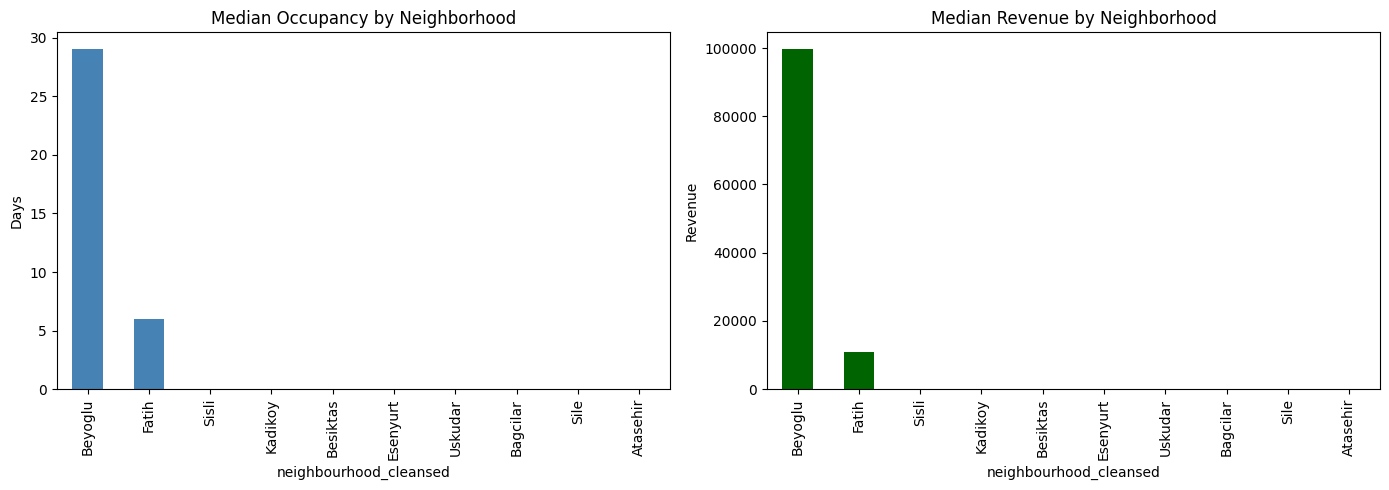

In [220]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

neigh_summary['median_occupancy'].sort_values(ascending=False).plot(kind='bar', ax=ax[0], color='steelblue')
ax[0].set_title('Median Occupancy by Neighborhood')
ax[0].set_ylabel('Days')

neigh_summary['median_revenue'].sort_values(ascending=False).plot(kind='bar', ax=ax[1], color='darkgreen')
ax[1].set_title('Median Revenue by Neighborhood')
ax[1].set_ylabel('Revenue')

plt.tight_layout()
plt.show()

In [221]:
active['room_type'].value_counts(normalize=True).round(2)

room_type
Entire home/apt    0.79
Private room       0.20
Hotel room         0.01
Shared room        0.00
Name: proportion, dtype: float64

In [222]:
inactive['room_type'].value_counts(normalize=True).round(2)

room_type
Entire home/apt    0.58
Private room       0.40
Hotel room         0.02
Shared room        0.01
Name: proportion, dtype: float64

### What it means


Active listings are much more concentrated in **entire homes/apartments**.


That suggests:



- whole places are more likely to get bookings

- private rooms are less active in this market

In [223]:
active['host_is_superhost'].value_counts(normalize=True).round(2)

host_is_superhost
False    0.6
True     0.4
Name: proportion, dtype: float64

In [224]:
inactive['host_is_superhost'].value_counts(normalize=True).round(2)

host_is_superhost
False    0.93
True     0.07
Name: proportion, dtype: float64

### What it means


Superhosts are much more common among active listings.


That suggests:



- being a Superhost is linked to better occupancy

- host quality matters a lot

- inactive listings are mostly non-Superhosts

**Beyoglu leads because it has the strongest concentration of entire homes and active Superhosts, which are associated with higher occupancy and revenue.**

### 1. Occupancy by neighborhood

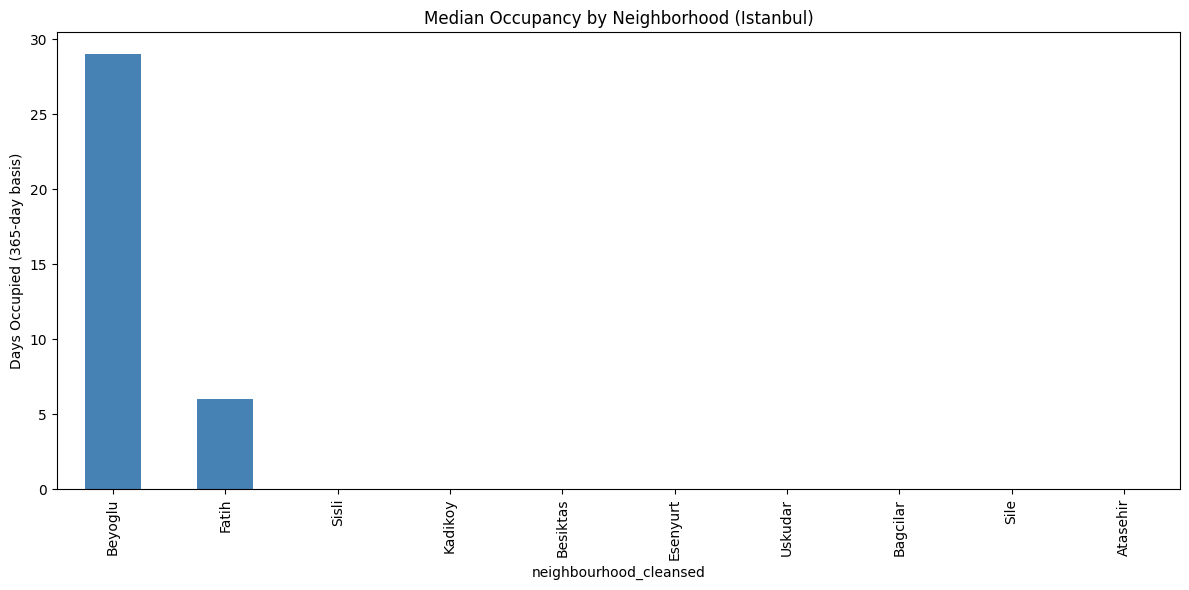

In [226]:
fig, ax = plt.subplots(figsize=(12, 6))
neigh_summary['median_occupancy'].sort_values(ascending=False).plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Median Occupancy by Neighborhood (Istanbul)')
ax.set_ylabel('Days Occupied (365-day basis)')
plt.tight_layout()
plt.savefig('visuals/occupancy_by_neighborhood.png', dpi=300, bbox_inches='tight')
plt.show()

**Report:** Beyoglu has the highest median occupancy, showing it is the most active market area. Most other neighborhoods are near zero.

### 2. Revenue by neighborhood

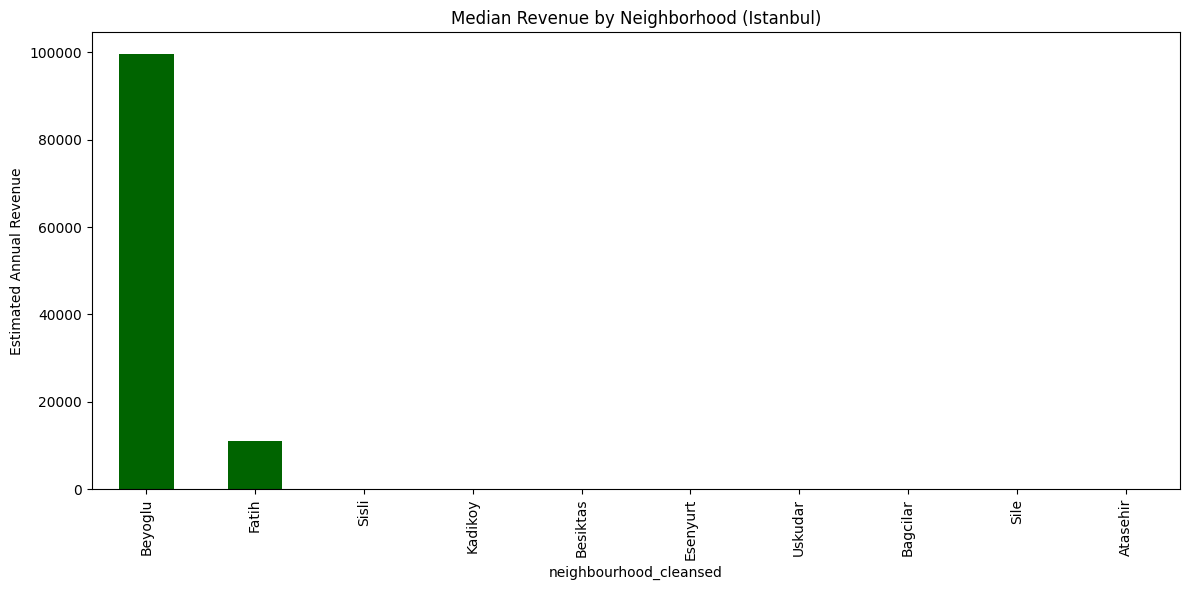

In [227]:
fig, ax = plt.subplots(figsize=(12, 6))
neigh_summary['median_revenue'].sort_values(ascending=False).plot(kind='bar', ax=ax, color='darkgreen')
ax.set_title('Median Revenue by Neighborhood (Istanbul)')
ax.set_ylabel('Estimated Annual Revenue')
plt.tight_layout()
plt.savefig('visuals/revenue_by_neighborhood.png', dpi=300, bbox_inches='tight')
plt.show()

**Report:** Beyoglu again leads in median revenue, with Fatih far behind. This suggests demand is concentrated in a small number of central areas.

### 3. Room type comparison

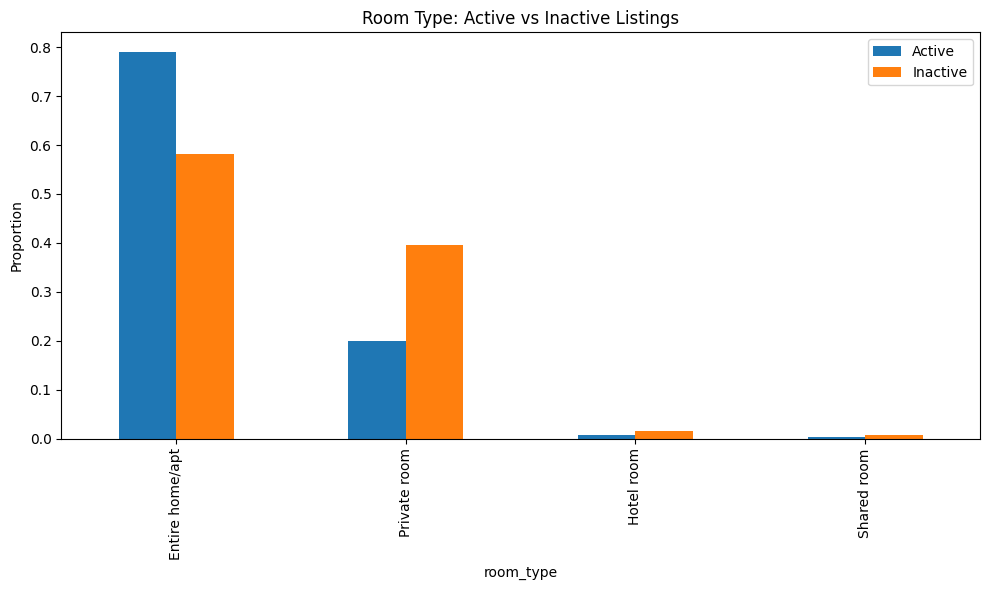

In [228]:
fig, ax = plt.subplots(figsize=(10, 6))

room_comp = pd.DataFrame({

'Active': active['room_type'].value_counts(normalize=True),

'Inactive': inactive['room_type'].value_counts(normalize=True)

})

room_comp.plot(kind='bar', ax=ax)

ax.set_title('Room Type: Active vs Inactive Listings')

ax.set_ylabel('Proportion')

plt.tight_layout()

plt.savefig('visuals/room_type_comparison.png', dpi=300, bbox_inches='tight')

plt.show()

**Report:** Active listings are dominated by entire homes/apartments, while inactive listings have more private rooms. Entire homes perform better.

### 4. Superhost impact

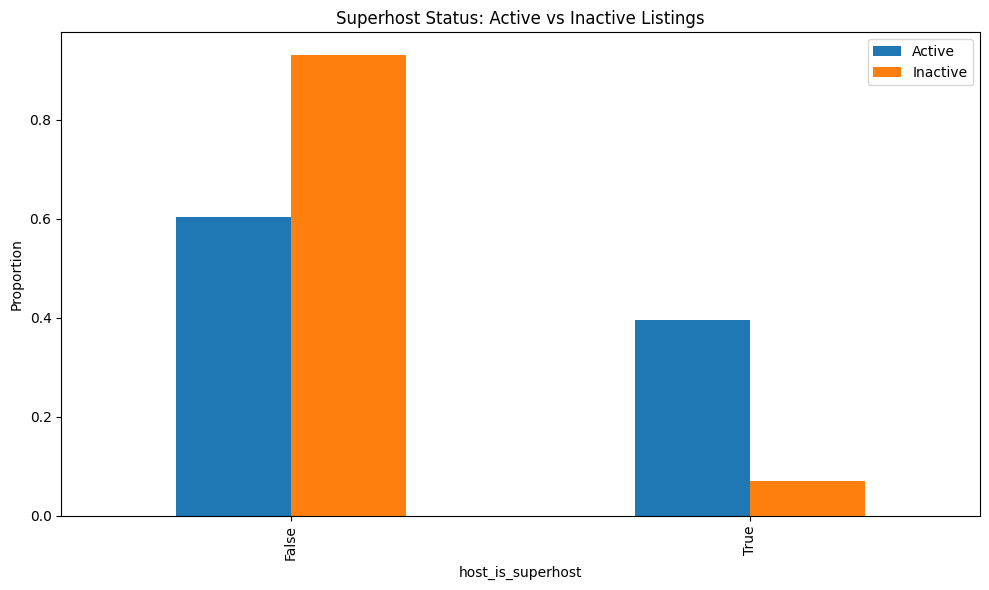

In [229]:
fig, ax = plt.subplots(figsize=(10, 6))

superhost_comp = pd.DataFrame({

'Active': active['host_is_superhost'].value_counts(normalize=True),

'Inactive': inactive['host_is_superhost'].value_counts(normalize=True)

})

superhost_comp.plot(kind='bar', ax=ax)

ax.set_title('Superhost Status: Active vs Inactive Listings')

ax.set_ylabel('Proportion')

plt.tight_layout()

plt.savefig('visuals/superhost_comparison.png', dpi=300, bbox_inches='tight')

plt.show()

**Report:** Superhosts make up a much larger share of active listings than inactive ones, so host quality is strongly linked to performance.

### 5. Price distribution

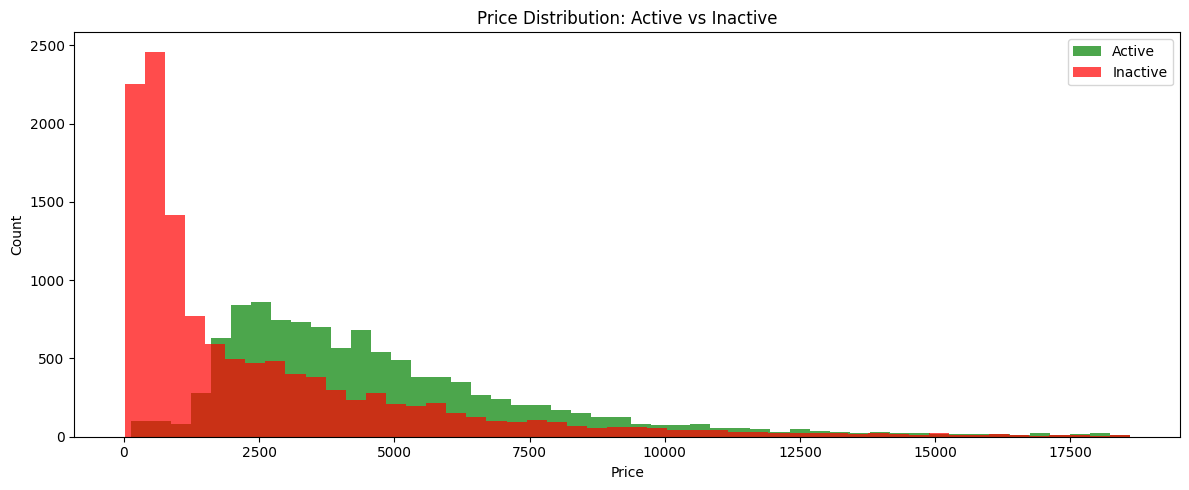

In [232]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(active['price'], bins=50, alpha=0.7, label='Active', color='green')

ax.hist(inactive['price'], bins=50, alpha=0.7, label='Inactive', color='red')

ax.set_xlabel('Price')

ax.set_ylabel('Count')

ax.set_title('Price Distribution: Active vs Inactive')

ax.legend()

plt.tight_layout()

plt.savefig('visuals/price_distribution.png', dpi=300, bbox_inches='tight')

plt.show()

**Report:** Active listings are priced higher than inactive ones, but the distribution is still skewed, so median is more reliable than mean.

## Key Findings

1. **Market concentration:** Active demand is heavily concentrated in a few areas, especially Beyoglu.
2. **Room type effect:** Active listings are mostly entire homes/apartments.
3. **Host quality effect:** Superhost share is much higher in active listings than inactive listings.
4. **Price-performance split:** Active listings have a much higher median price than inactive listings.

## Business Recommendations

- Prioritize neighborhoods with proven occupancy performance.
- Favor listing formats aligned with active demand (entire home/apt).
- Improve host trust signals (Superhost pathway, response quality).
- Use neighborhood-aware pricing instead of one generic pricing strategy.



## Final Insights

### 1. Beyoglu is the strongest market
Beyoglu has the highest number of active listings, the highest median occupancy, and the highest median revenue. This makes it the most attractive neighborhood for Airbnb performance in Istanbul.

### 2. Entire homes perform better
Active listings are mostly entire homes/apartments, while inactive listings contain more private rooms. Larger, whole-property listings appear to attract more bookings.

### 3. Superhost status matters
Superhosts are much more common among active listings than inactive ones. Host reputation is a strong signal of success.

### 4. Price and performance are linked
Active listings have a much higher median price than inactive listings. However, price alone is not enough — location and host quality also matter.

### 5. Most listings are inactive
More than half of the listings have zero estimated occupancy. This shows the Istanbul short-term rental market is competitive and concentrated in a few strong areas.

## Conclusion

**This analysis shows that Airbnb success in Istanbul is driven by neighborhood, room type, and host quality. Beyoglu stands out as the strongest area, especially for entire homes hosted by Superhosts. For a new host, the best strategy is to focus on high-demand neighborhoods, offer full-property stays, and build a strong reputation**